In [4]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt

In [5]:
npzfile = np.load(r'/home/cameron/Desktop/research/rfsoc_analysis/tmp/ddfs_rdfs.npz')
ddfs = npzfile['ddfs']
rdfs = npzfile['rdfs']

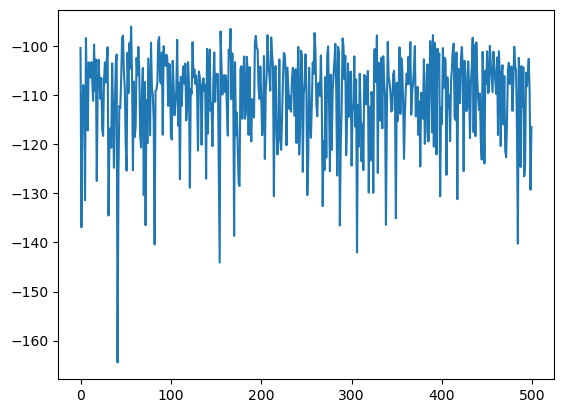

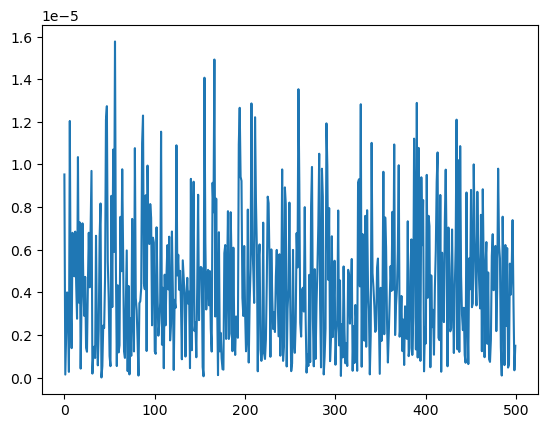

In [6]:
fig, ax = plt.subplots()
ax.plot(20*np.log10(np.abs(ddfs)))
plt.show()

fig, ax = plt.subplots()
ax.plot(np.abs(ddfs))
plt.show()

In [8]:
indices = np.arange(ddfs.size)
mask = np.abs(ddfs) > 0.0001
bad_ddfs = ddfs[mask]
bad_indices = indices[mask]
print(bad_ddfs)
print(bad_indices)

print(np.std(ddfs))

[]
[]
5.45265193647701e-06


In [5]:
print(ddfs[61])
print(rdfs.shape)
print(rdfs[:,61])

-0.0006481700350777343
(2, 500)
[0.00019952 0.00111617]


In [19]:
big_numpy_file = np.load(r'/home/cameron/Desktop/research/rfsoc_analysis/data/big_buffer_500pairs.npy')

NUM_SAMP = big_numpy_file.shape[2]
SAMP_FREQ = 4e9 / 16
NUM_PAIRS = big_numpy_file.shape[0]

iq_data = np.zeros((2, NUM_PAIRS, NUM_SAMP), dtype=np.complex128)
iq_data[0] = big_numpy_file[:,0,:] + 1j*big_numpy_file[:,1,:]
iq_data[1] = big_numpy_file[:,2,:] + 1j*big_numpy_file[:,3,:]

big_numpy_file = None

FREQ_DOMAIN = fftfreq(NUM_SAMP, 1/SAMP_FREQ)
iq_data_freq = fft(iq_data, axis=2)
carrier_indices = np.argmax(np.abs(iq_data_freq), axis=2)
carrier_freqs = FREQ_DOMAIN[carrier_indices]
row_inds = np.arange(2)[:,None]
col_inds = np.arange(NUM_PAIRS)
carrier_phases = np.abs(np.angle(iq_data_freq[row_inds, col_inds, carrier_indices]))
iq_data = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs[:,:,np.newaxis]/SAMP_FREQ*np.arange(NUM_SAMP) + carrier_phases[:,:,np.newaxis]))
avg_phases = np.average(np.angle(iq_data), axis=2)
iq_data = np.exp(-1j*avg_phases[:,:,np.newaxis])*iq_data

row_inds, col_inds = None, None
avg_phases, carrier_freqs, carrier_phases = None, None, None


In [21]:
print(iq_data.shape)
bad_data = iq_data[:,22,:]

(2, 500, 262144)


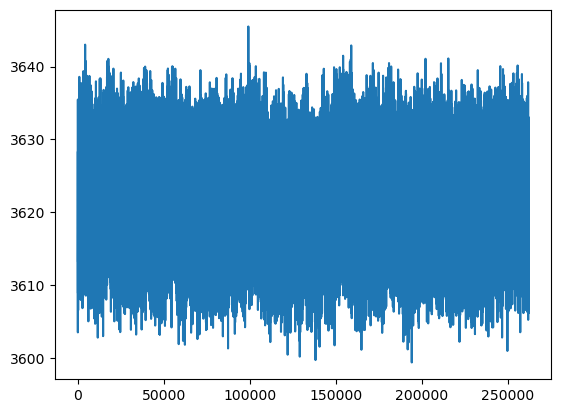

In [25]:
fig, ax = plt.subplots()
ax.plot(np.abs(bad_data[0,:]))
plt.show()